### Important DataFrame Methods

In [87]:
# value_counts
# sort_values
# rank
# sort index
# set index
# rename index -> rename
# reset index
# unique & nunique
# isnull/notnull/hasnans
# dropna
# fillna
# drop_duplicates
# drop
# apply
# isin
# corr
# nlargest -> nsmallest
# insert
# copy

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plot

### value_counts()

In [89]:
# value_counts(Applicable both dataframes and series)
a = pd.Series([1,1,1,2,2,3,4])
a.value_counts()

# Shows the number of occurence of each unique item in a Series or DataFrame

1    3
2    2
3    1
4    1
Name: count, dtype: int64

In [90]:
marks = pd.DataFrame([
    [100,80,10],
    [90,70,7],
    [120,100,14],
    [80,70,14],
    [80,70,14]
],columns=['iq','marks','package'])
marks

,iq,marks,package
0,100,80,10
1,90,70,7
2,120,100,14
3,80,70,14
4,80,70,14


In [91]:
marks.value_counts()

iq   marks  package
80   70     14         2
90   70     7          1
100  80     10         1
120  100    14         1
Name: count, dtype: int64

In [92]:
# find which player has won most potm -> in finals and qualifiers
ipl = pd.read_csv("./ipl-matches.csv")
man_of_the_match_players = ipl[~ipl['MatchNumber'].str.isdigit()]['Player_of_Match'].value_counts()
man_of_the_match_players.nlargest()
# ipl.info() 

Player_of_Match
F du Plessis      3
SK Raina          3
KA Pollard        3
JJ Bumrah         2
AB de Villiers    2
Name: count, dtype: int64

<Axes: ylabel='count'>

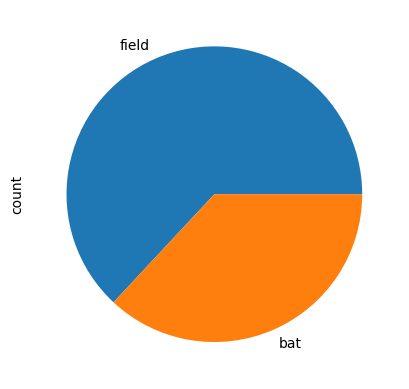

In [93]:
# TossDecision plot
toss_counts = ipl['TossDecision'].value_counts().plot(kind='pie')
toss_counts

In [94]:
# how many matches have each team played
(ipl['Team1'].value_counts() + ipl['Team2'].value_counts()).sort_values(ascending=False)


Mumbai Indians                 231
Royal Challengers Bangalore    226
Kolkata Knight Riders          223
Chennai Super Kings            208
Rajasthan Royals               192
Kings XI Punjab                190
Delhi Daredevils               161
Sunrisers Hyderabad            152
Deccan Chargers                 75
Delhi Capitals                  63
Pune Warriors                   46
Gujarat Lions                   30
Punjab Kings                    28
Gujarat Titans                  16
Rising Pune Supergiant          16
Lucknow Super Giants            15
Kochi Tuskers Kerala            14
Rising Pune Supergiants         14
Name: count, dtype: int64

### Sorting -> sort_values()

In [95]:
movies = pd.read_csv('./movies.csv')
movies.sort_values('title_x')

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
1498,16 December (film),tt0313844,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/16_December_(film),16-Dec,16-Dec,0,2002,158,Action|Thriller,6.9,1091,16 December 1971 was the day when India won t...,Indian intelligence agents race against time t...,NaN,Danny Denzongpa|Gulshan Grover|Milind Soman|Di...,2 nominations,22 March 2002 (India)
1021,1920 (film),tt1301698,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/1920_(film),1920,1920,0,2008,138,Horror|Mystery|Romance,6.4,2588,A devotee of Bhagwan Shri Hanuman Arjun Singh...,After forsaking his family and religion a hus...,A Love Made in Heaven...A Revenge Born in Hell...,Rajniesh Duggall|Adah Sharma|Anjori Alagh|Raj ...,NaN,12 September 2008 (India)
287,1920: London,tt5638500,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/1920_London,1920 London,1920 London,0,2016,120,Horror|Mystery,4.1,1373,Shivangi (Meera Chopra) lives in London with h...,After her husband is possessed by an evil spir...,Fear strikes again,Sharman Joshi|Meera Chopra|Vishal Karwal|Suren...,NaN,6 May 2016 (USA)
723,1920: The Evil Returns,tt2222550,https://upload.wikimedia.org/wikipedia/en/e/e7...,https://en.wikipedia.org/wiki/1920:_The_Evil_R...,1920: Evil Returns,1920: Evil Returns,0,2012,124,Drama|Horror|Romance,4.8,1587,This story revolves around a famous poet who m...,This story revolves around a famous poet who m...,Possession is back,Vicky Ahuja|Tia Bajpai|Irma Jämhammar|Sharad K...,NaN,2 November 2012 (India)
1039,1971 (2007 film),tt0983990,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/1971_(2007_film),1971,1971,0,2007,160,Action|Drama|War,7.9,1121,Based on true facts the film revolves around ...,Based on true facts the film revolves around ...,Honor the heroes.......,Manoj Bajpayee|Ravi Kishan|Deepak Dobriyal|,1 win,9 March 2007 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
778,Zindagi Na Milegi Dobara,tt1562872,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zindagi_Na_Mileg...,Zindagi Na Milegi Dobara,Zindagi Na Milegi Dobara,0,2011,155,Comedy|Drama,8.1,60826,Three friends decide to turn their fantasy vac...,Three friends decide to turn their fantasy vac...,NaN,Hrithik Roshan|Farhan Akhtar|Abhay Deol|Katrin...,30 wins & 22 nominations,15 July 2011 (India)
670,Zindagi Tere Naam,tt2164702,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zindagi_Tere_Naam,Zindagi Tere Naam,Zindagi Tere Naam,0,2012,120,Romance,4.7,27,Mr. Singh an elderly gentleman relates to hi...,Mr. Singh an elderly gentleman relates to hi...,NaN,Mithun Chakraborty|Ranjeeta Kaur|Priyanka Meht...,1 win,16 March 2012 (India)
756,Zokkomon,tt1605790,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zokkomon,Zokkomon,Zokkomon,0,2011,109,Action|Adventure,4.0,274,After the passing of his parents in an acciden...,An orphan is abused and abandoned believed to...,Betrayal. Friendship. Bravery.,Darsheel Safary|Anupam Kher|Manjari Fadnnis|Ti...,NaN,22 April 2011 (India)
939,Zor Lagaa Ke...Haiya!,tt1479857,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zor_Lagaa_Ke...H...,Zor Lagaa Ke... Haiya!,Zor Lagaa Ke... Haiya!,0,2009,\N,Comedy|Drama|Family,6.4,46,A tree narrates the story of four Mumbai-based...,Children build a tree-house to spy on a beggar...,NaN,Meghan Jadhav|Mithun Chakraborty|Riya Sen|Seem...,NaN,NaN


In [96]:
# data with nan values
students = pd.DataFrame(
    {
        'name':['nitish','ankit','rupesh',np.nan,'mrityunjay',np.nan,'rishabh',np.nan,'aditya',np.nan],
        'college':['bit','iit','vit',np.nan,np.nan,'vlsi','ssit',np.nan,np.nan,'git'],
        'branch':['eee','it','cse',np.nan,'me','ce','civ','cse','bio',np.nan],
        'cgpa':[6.66,8.25,6.41,np.nan,5.6,9.0,7.4,10,7.4,np.nan],
        'package':[4,5,6,np.nan,6,7,8,9,np.nan,np.nan]

    }
)

students

,name,college,branch,cgpa,package
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0
2,rupesh,vit,cse,6.41,6.0
3,NaN,NaN,NaN,NaN,NaN
4,mrityunjay,NaN,me,5.60,6.0
5,NaN,vlsi,ce,9.00,7.0
6,rishabh,ssit,civ,7.40,8.0
7,NaN,NaN,cse,10.00,9.0
8,aditya,NaN,bio,7.40,NaN
9,NaN,git,NaN,NaN,NaN


In [97]:
students.sort_values('name',na_position='first',ascending=False,inplace=True)
students
# na_position -> shows the nan values at the end by default
# inplace -> Helps toapply the sorting changes permanently to the data set

,name,college,branch,cgpa,package
3,NaN,NaN,NaN,NaN,NaN
5,NaN,vlsi,ce,9.00,7.0
7,NaN,NaN,cse,10.00,9.0
9,NaN,git,NaN,NaN,NaN
2,rupesh,vit,cse,6.41,6.0
6,rishabh,ssit,civ,7.40,8.0
0,nitish,bit,eee,6.66,4.0
4,mrityunjay,NaN,me,5.60,6.0
1,ankit,iit,it,8.25,5.0
8,aditya,NaN,bio,7.40,NaN


In [98]:
# sorting movies with year of release first then alphabeticaly
movies.sort_values(['year_of_release','title_x'],ascending=[True,False])
# movies.info()

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
1623,Zubeidaa,tt0255713,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zubeidaa,Zubeidaa,Zubeidaa,0,2001,153,Biography|Drama|History,6.2,1384,The film begins with Riyaz (Rajat Kapoor) Zub...,Zubeidaa an aspiring Muslim actress marries ...,The Story of a Princess,Karisma Kapoor|Rekha|Manoj Bajpayee|Rajit Kapo...,3 wins & 13 nominations,19 January 2001 (India)
1625,Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
1622,Yeh Teraa Ghar Yeh Meraa Ghar,tt0298606,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Teraa_Ghar_Y...,Yeh Teraa Ghar Yeh Meraa Ghar,Yeh Teraa Ghar Yeh Meraa Ghar,0,2001,175,Comedy|Drama,5.7,704,In debt; Dayashankar Pandey is forced to go to...,In debt; Dayashankar Pandey is forced to go to...,NaN,Sunil Shetty|Mahima Chaudhry|Paresh Rawal|Saur...,1 nomination,12 October 2001 (India)
1620,Yeh Raaste Hain Pyaar Ke,tt0292740,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Raaste_Hain_...,Yeh Raaste Hain Pyaar Ke,Yeh Raaste Hain Pyaar Ke,0,2001,149,Drama|Romance,4.0,607,Two con artistes and car thieves Vicky (Ajay ...,Two con artistes and car thieves Vicky (Ajay ...,Love is a journey... not a destination,Ajay Devgn|Madhuri Dixit|Preity Zinta|Vikram G...,NaN,10 August 2001 (India)
1573,Yaadein (2001 film),tt0248617,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yaadein_(2001_film),Yaadein...,Yaadein...,0,2001,171,Drama|Musical|Romance,4.4,3034,Raj Singh Puri is best friends with L.K. Malho...,Raj Singh Puri is best friends with L.K. Malho...,memories to cherish...,Jackie Shroff|Hrithik Roshan|Kareena Kapoor|Am...,1 nomination,27 June 2001 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,Article 15 (film),tt10324144,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Article_15_(film),Article 15,Article 15,0,2019,130,Crime|Drama,8.3,13417,In the rural heartlands of India an upright p...,In the rural heartlands of India an upright p...,Farq Bahut Kar Liya| Ab Farq Laayenge.,Ayushmann Khurrana|Nassar|Manoj Pahwa|Kumud Mi...,1 win,28 June 2019 (USA)
46,Arjun Patiala,tt7881524,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Arjun_Patiala,Arjun Patiala,Arjun Patiala,0,2019,107,Action|Comedy,4.1,676,Arjun Patiala(Diljit Dosanjh)has recently been...,This spoof comedy narrates the story of a cop ...,NaN,Diljit Dosanjh|Kriti Sanon|Varun Sharma|Ronit ...,NaN,26 July 2019 (USA)
10,Amavas,tt8396186,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Amavas,Amavas,Amavas,0,2019,134,Horror|Thriller,2.8,235,Far away from the bustle of the city a young ...,The lives of a couple turn into a nightmare a...,NaN,Ali Asgar|Vivan Bhatena|Nargis Fakhri|Sachiin ...,NaN,8 February 2019 (India)
26,Albert Pinto Ko Gussa Kyun Aata Hai?,tt4355838,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Albert_Pinto_Ko_...,Albert Pinto Ko Gussa Kyun Aata Hai?,Albert Pinto Ko Gussa Kyun Aata Hai?,0,2019,100,Drama,4.8,56,Albert leaves his house one morning without te...,Albert Pinto goes missing one day and his girl...,NaN,Manav Kaul|Nandita Das|,NaN,12 April 2019 (India)


### Rank -> rank() (applicable on only on series)

In [99]:
batsman_data = pd.read_csv('./batsman_runs_ipl.csv')
batsman_data.head(5)

,batter,batsman_run
0,A Ashish Reddy,280
1,A Badoni,161
2,A Chandila,4
3,A Chopra,53
4,A Choudhary,25


In [100]:
batsman_data['batsman_rank'] = batsman_data['batsman_run'].rank(ascending=False)
batsman_data.sort_values('batsman_rank')

,batter,batsman_run,batsman_rank
569,V Kohli,6634,1.0
462,S Dhawan,6244,2.0
130,DA Warner,5883,3.0
430,RG Sharma,5881,4.0
493,SK Raina,5536,5.0
...,...,...,...
570,V Pratap Singh,0,594.0
63,Abdur Razzak,0,594.0
562,U Kaul,0,594.0
65,Akash Deep,0,594.0


### sort_index() -> applicable for both Series and dataframes and works similarly

In [101]:
marks_info = {
    'maths':67,
    'english':57,
    'science':89,
    'hindi':100
}

marks_series = pd.Series(marks_info)
marks_series

maths       67
english     57
science     89
hindi      100
dtype: int64

In [102]:
marks_series.sort_index()

english     57
hindi      100
maths       67
science     89
dtype: int64

### Set and Reset

In [103]:
# set_index(sataframe)
batsman_data.set_index('batter',inplace=True)
batsman_data

,batsman_run,batsman_rank
batter,,
A Ashish Reddy,280,166.5
A Badoni,161,226.0
A Chandila,4,535.0
A Chopra,53,329.0
A Choudhary,25,402.5
...,...,...
Yash Dayal,0,594.0
Yashpal Singh,47,343.0
Younis Khan,3,547.5


In [104]:
# reset_index(dataframe,series)
batsman_data.reset_index().set_index('batsman_rank')


,batter,batsman_run
batsman_rank,,
166.5,A Ashish Reddy,280
226.0,A Badoni,161
535.0,A Chandila,4
329.0,A Chopra,53
402.5,A Choudhary,25
...,...,...
594.0,Yash Dayal,0
343.0,Yashpal Singh,47
547.5,Younis Khan,3


In [105]:
marks_data = marks_series.reset_index()
type(marks_data)
# converting Series into a Dataframe using reset_index()

pandas.core.frame.DataFrame

### rename()

In [106]:
# reanming all cloumns at a time
marks_data.columns = ['Subject','Marks']
marks_data

,Subject,Marks
0,maths,67
1,english,57
2,science,89
3,hindi,100


In [107]:
# for renaming specific icolumn indecies

# renaming imdb_id -> imdb, poster_path -> link
movies.rename(columns={"imdb_id":"imdb","poster_path":"link"},inplace=True)

In [108]:
movies.set_index('title_x',inplace=True)

In [109]:
# renaming values of rows

movies.rename(index={'Uri: The Surgical Strike':'Uri', 'Battalion 609':'Battalion'},inplace=True)
movies.head(3)

,imdb,link,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
title_x,,,,,,,,,,,,,,,,,
Uri,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
Battalion,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)


### unique() applicable only to Series

- Gives all unique values

In [110]:
x = pd.Series([1,2,4,4,5,5,5,5,5,7,8,np.nan,np.nan])
x.unique()

array([ 1.,  2.,  4.,  5.,  7.,  8., nan])

In [111]:
len(batsman_data['batsman_run'].unique())
# 317 different types of Run scores

317

### nunique(series + dataframe) -> does not count nan -> dropna parameter

In [112]:
ipl['Season'].nunique()

15

In [113]:
x.nunique()

6

### isnull(series + dataframe) & notnull(series + dataframe) & hasnans(series)

In [114]:
students['name'].isnull()

3     True
5     True
7     True
9     True
2    False
6    False
0    False
4    False
1    False
8    False
Name: name, dtype: bool

In [115]:
# notnull is inverse of isnull()
students['name'].notnull()

3    False
5    False
7    False
9    False
2     True
6     True
0     True
4     True
1     True
8     True
Name: name, dtype: bool

In [116]:
# hasnans shows whether a column has null vaulues or not
students['name'].hasnans

True

In [117]:
# on dataframes
students.isnull()

,name,college,branch,cgpa,package
3,True,True,True,True,True
5,True,False,False,False,False
7,True,True,False,False,False
9,True,False,True,True,True
2,False,False,False,False,False
6,False,False,False,False,False
0,False,False,False,False,False
4,False,True,False,False,False
1,False,False,False,False,False
8,False,True,False,False,True


In [118]:
students.notnull()

,name,college,branch,cgpa,package
3,False,False,False,False,False
5,False,True,True,True,True
7,False,False,True,True,True
9,False,True,False,False,False
2,True,True,True,True,True
6,True,True,True,True,True
0,True,True,True,True,True
4,True,False,True,True,True
1,True,True,True,True,True
8,True,False,True,True,False


### dropna(series + dataframe) -> how parameter -> works like or

In [119]:
students['name'].dropna()

2        rupesh
6       rishabh
0        nitish
4    mrityunjay
1         ankit
8        aditya
Name: name, dtype: object

In [120]:
students.dropna(how="all")
#if all values has a null value then whole row get's dropped

,name,college,branch,cgpa,package
5,NaN,vlsi,ce,9.00,7.0
7,NaN,NaN,cse,10.00,9.0
9,NaN,git,NaN,NaN,NaN
2,rupesh,vit,cse,6.41,6.0
6,rishabh,ssit,civ,7.40,8.0
0,nitish,bit,eee,6.66,4.0
4,mrityunjay,NaN,me,5.60,6.0
1,ankit,iit,it,8.25,5.0
8,aditya,NaN,bio,7.40,NaN


In [121]:
students.dropna(subset=['name','college'])

,name,college,branch,cgpa,package
2,rupesh,vit,cse,6.41,6.0
6,rishabh,ssit,civ,7.40,8.0
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0


### fillna(series + dataframe)

In [122]:
### on series
students['name'].fillna('unknown')

3       unknown
5       unknown
7       unknown
9       unknown
2        rupesh
6       rishabh
0        nitish
4    mrityunjay
1         ankit
8        aditya
Name: name, dtype: object

In [123]:
# on dataframe
values = {'name':'unknown','college':'unknown','branch':'not-mentioned','cgpa':4.0,"package":3.0}
students.fillna(value=values)

,name,college,branch,cgpa,package
3,unknown,unknown,not-mentioned,4.00,3.0
5,unknown,vlsi,ce,9.00,7.0
7,unknown,unknown,cse,10.00,9.0
9,unknown,git,not-mentioned,4.00,3.0
2,rupesh,vit,cse,6.41,6.0
6,rishabh,ssit,civ,7.40,8.0
0,nitish,bit,eee,6.66,4.0
4,mrityunjay,unknown,me,5.60,6.0
1,ankit,iit,it,8.25,5.0
8,aditya,unknown,bio,7.40,3.0


In [124]:
students['name'].fillna(method="bfill")
# bfill and ffill is hidden parameters

/tmp/ipykernel_24089/2715550476.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  students['name'].fillna(method="bfill")


3        rupesh
5        rupesh
7        rupesh
9        rupesh
2        rupesh
6       rishabh
0        nitish
4    mrityunjay
1         ankit
8        aditya
Name: name, dtype: object

### drop_duplicates(series + dataframe) -> works like and -> duplicated()

In [129]:
marks

,iq,marks,package
0,100,80,10
1,90,70,7
2,120,100,14
3,80,70,14
4,80,70,14


In [130]:
temp = pd.Series([1,1,1,1,2,3,4,5,2,3,4,8,9])
temp.drop_duplicates()

0     1
4     2
5     3
6     4
7     5
11    8
12    9
dtype: int64

In [128]:
marks.drop_duplicates()

,iq,marks,package
0,100,80,10
1,90,70,7
2,120,100,14
3,80,70,14


In [143]:
# find the last match played by Virat Kholi in delhi
ipl['allPlayers'] = ipl['Team1Players'] + ipl['Team2Players']
ipl['allPlayers']

0      ['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...
1      ['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...
2      ['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...
3      ['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...
4      ['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...
                             ...                        
945    ['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...
946    ['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...
947    ['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...
948    ['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...
949    ['R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis...
Name: allPlayers, Length: 950, dtype: object

In [155]:
# 1st approach
matches_played_by_kohli = ipl['allPlayers'].str.contains("V Kohli")
matches_played_in_delhi = ipl['City'] == 'Delhi'
matches_kohli_played_at_delhi = ipl[matches_played_in_delhi & matches_played_in_delhi]
matches_kohli_played_at_delhi[["City","allPlayers"]]

,City,allPlayers
106,Delhi,"['JC Buttler', 'YBK Jaiswal', 'SV Samson', 'R ..."
107,Delhi,"['RD Gaikwad', 'F du Plessis', 'MM Ali', 'SK R..."
110,Delhi,"['JC Buttler', 'YBK Jaiswal', 'SV Samson', 'S ..."
111,Delhi,"['DA Warner', 'JM Bairstow', 'MK Pandey', 'KS ..."
201,Delhi,"['AM Rahane', 'LS Livingstone', 'SV Samson', '..."
...,...,...
910,Delhi,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'TM Dils..."
913,Delhi,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MF Maha..."
921,Delhi,"['G Gambhir', 'V Sehwag', 'AB de Villiers', 'S..."
933,Delhi,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'Shoaib ..."


In [156]:
def did_player_play(player_name,player_list):
    return player_name in player_list

In [187]:
ipl['did_kohli_play'] = ipl['allPlayers'].apply(lambda players:did_player_play("V Kohli",players))
# ipl['allPlayers'].str.contains('S Dhawan')
matches_played_by_kohli_at_delhi = ipl[(ipl['City'] == 'Delhi') & (ipl['did_kohli_play'] == True)]
last_match_kohli_played_at_delhi = matches_played_by_kohli_at_delhi.sort_values('Date',ascending=False).drop_duplicates(subset=['City','did_kohli_play'],keep='first')
last_match_kohli_played_at_delhi

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,...,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,allPlayers,did_kohli_play
208,1178421,Delhi,2019-04-28,2019,46,Delhi Capitals,Royal Challengers Bangalore,Arun Jaitley Stadium,Delhi Capitals,bat,...,Runs,16.0,NaN,S Dhawan,"['PP Shaw', 'S Dhawan', 'SS Iyer', 'RR Pant', ...","['PA Patel', 'V Kohli', 'AB de Villiers', 'S D...",BNJ Oxenford,KN Ananthapadmanabhan,"['PP Shaw', 'S Dhawan', 'SS Iyer', 'RR Pant', ...",True


### drop()

In [193]:
# on series using index
temp.drop(index=[2,12])


0     1
1     1
3     1
4     2
5     3
6     4
7     5
8     2
9     3
10    4
11    8
dtype: int64

In [199]:
# on dataframe using column
# did_kohli_play column dropped
ipl.drop(columns='did_kohli_play').head(1)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,...,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,allPlayers
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,...,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ..."


In [205]:
students.set_index('name').drop(index=['ankit',np.nan])
# ankit and nan in name index got dropped

,college,branch,cgpa,package
name,,,,
rupesh,vit,cse,6.41,6.0
rishabh,ssit,civ,7.40,8.0
nitish,bit,eee,6.66,4.0
mrityunjay,NaN,me,5.60,6.0
aditya,NaN,bio,7.40,NaN


### apply()

In [206]:
temp = pd.Series([10,20,30,40,50])
temp

0    10
1    20
2    30
3    40
4    50
dtype: int64

In [207]:
def sigmoid(value):
    res = 1/1 + np.exp(-value)
    return res

In [208]:
temp.apply(sigmoid)

0    1.000045
1    1.000000
2    1.000000
3    1.000000
4    1.000000
dtype: float64

In [209]:
# on dataframe 

points_df = pd.DataFrame(
    {
        '1st point':[(3,4),(-6,5),(0,0),(-10,1),(4,5)],
        '2nd point':[(-3,4),(0,0),(2,2),(10,10),(1,1)]
    }
)

points_df

,1st point,2nd point
0,"(3, 4)","(-3, 4)"
1,"(-6, 5)","(0, 0)"
2,"(0, 0)","(2, 2)"
3,"(-10, 1)","(10, 10)"
4,"(4, 5)","(1, 1)"


In [212]:
# add a new column which shows the Euclidean distance between points
def euclidean_distance(row):
    pt_A = row['1st point']
    pt_B = row['2nd point']
    d = np.sqrt((pt_B[0] - pt_A[0])**2 + (pt_B[1] - pt_A[1])**2)
    return d

In [216]:
points_df["euclidean distance"] = points_df.apply(euclidean_distance,axis=1)
points_df

,1st point,2nd point,euclidean distance
0,"(3, 4)","(-3, 4)",6.000000
1,"(-6, 5)","(0, 0)",7.810250
2,"(0, 0)","(2, 2)",2.828427
3,"(-10, 1)","(10, 10)",21.931712
4,"(4, 5)","(1, 1)",5.000000


### isin(series)

### corr


### nlargest and nsmallest(series and dataframe)

### insert(dataframe)


### copy(series + dataframe)